<a href="https://www.kaggle.com/code/fredericnicholson/give-me-more-cookies?scriptVersionId=238810518" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
import numpy as np # linear algebra
import polars as pl # data processing, CSV file I/O (e.g. pd.read_csv)
import polars.selectors as cs

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/playground-series-s5e5/sample_submission.csv
/kaggle/input/playground-series-s5e5/train.csv
/kaggle/input/playground-series-s5e5/test.csv


## Loading and brief analysis 

In [2]:
train_df = pl.read_csv("/kaggle/input/playground-series-s5e5/train.csv")
test_df = pl.read_csv("/kaggle/input/playground-series-s5e5/test.csv")
sample_submission_df = pl.read_csv("/kaggle/input/playground-series-s5e5/sample_submission.csv")
print (f"{train_df.shape = }, {test_df.shape = }")
with pl.Config (tbl_cols = 20) :
    print (train_df.head(20))

train_df.shape = (750000, 9), test_df.shape = (250000, 8)
shape: (20, 9)
┌─────┬────────┬─────┬────────┬────────┬──────────┬────────────┬───────────┬──────────┐
│ id  ┆ Sex    ┆ Age ┆ Height ┆ Weight ┆ Duration ┆ Heart_Rate ┆ Body_Temp ┆ Calories │
│ --- ┆ ---    ┆ --- ┆ ---    ┆ ---    ┆ ---      ┆ ---        ┆ ---       ┆ ---      │
│ i64 ┆ str    ┆ i64 ┆ f64    ┆ f64    ┆ f64      ┆ f64        ┆ f64       ┆ f64      │
╞═════╪════════╪═════╪════════╪════════╪══════════╪════════════╪═══════════╪══════════╡
│ 0   ┆ male   ┆ 36  ┆ 189.0  ┆ 82.0   ┆ 26.0     ┆ 101.0      ┆ 41.0      ┆ 150.0    │
│ 1   ┆ female ┆ 64  ┆ 163.0  ┆ 60.0   ┆ 8.0      ┆ 85.0       ┆ 39.7      ┆ 34.0     │
│ 2   ┆ female ┆ 51  ┆ 161.0  ┆ 64.0   ┆ 7.0      ┆ 84.0       ┆ 39.8      ┆ 29.0     │
│ 3   ┆ male   ┆ 20  ┆ 192.0  ┆ 90.0   ┆ 25.0     ┆ 105.0      ┆ 40.7      ┆ 140.0    │
│ 4   ┆ female ┆ 38  ┆ 166.0  ┆ 61.0   ┆ 25.0     ┆ 102.0      ┆ 40.6      ┆ 146.0    │
│ …   ┆ …      ┆ …   ┆ …      ┆ …      ┆ …     

In [3]:
display (train_df.select(cs.numeric()).describe())

statistic,id,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
str,f64,f64,f64,f64,f64,f64,f64,f64
"""count""",750000.0,750000.0,750000.0,750000.0,750000.0,750000.0,750000.0,750000.0
"""null_count""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""mean""",374999.5,41.420404,174.697685,75.145668,15.421015,95.483995,40.036253,88.282781
"""std""",216506.495284,15.175049,12.824496,13.982704,8.354095,9.449845,0.779875,62.395349
"""min""",0.0,20.0,126.0,36.0,1.0,67.0,37.1,1.0
"""25%""",187500.0,28.0,164.0,63.0,8.0,88.0,39.6,34.0
"""50%""",375000.0,40.0,174.0,74.0,15.0,95.0,40.3,77.0
"""75%""",562499.0,52.0,185.0,87.0,23.0,103.0,40.7,136.0
"""max""",749999.0,79.0,222.0,132.0,30.0,128.0,41.5,314.0


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-l

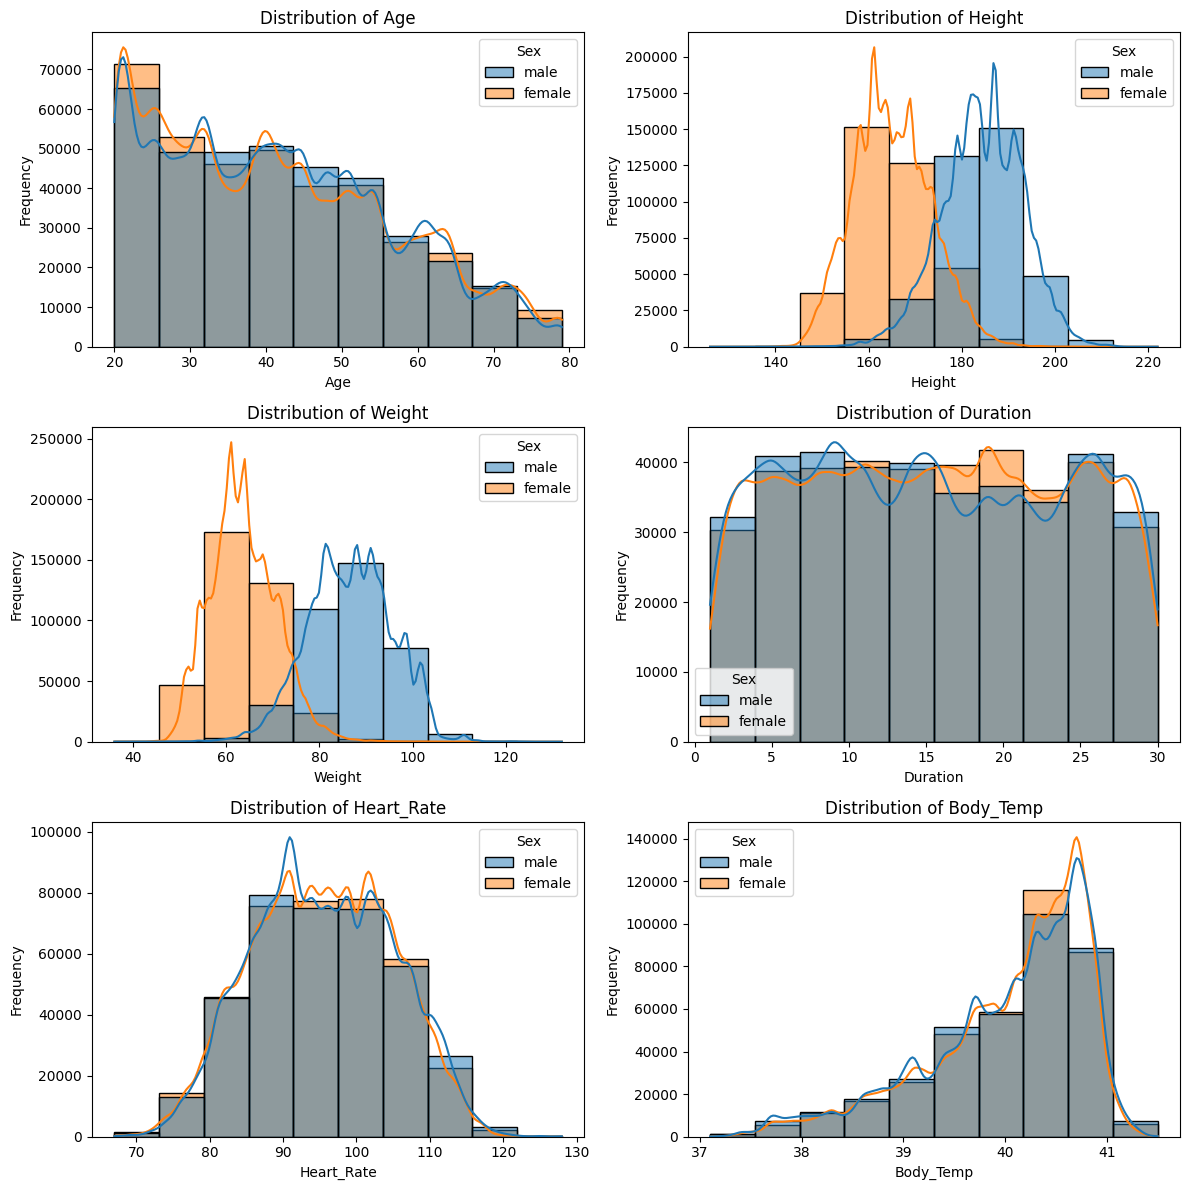

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt
# Number of columns for the subplot grid
num_cols = 2
features = ["Age", "Height", "Weight", "Duration", "Heart_Rate", "Body_Temp"]


# Calculate the number of rows needed for the subplots
num_rows = (len(features) + num_cols - 1) // num_cols  # Ceiling division



# Create the subplots
fig, axes = plt.subplots(num_rows, num_cols, figsize=(12, 4 * num_rows))  # Adjust figsize as needed

# Flatten the axes array to easily iterate over it
axes = axes.flatten()

# Iterate through the features and create histograms
for i, feature in enumerate(features):
    sns.histplot(data=train_df.to_pandas(), x=feature, ax=axes[i], hue = 'Sex', kde=True, bins = 10)  # Added kde=True for density curve
    axes[i].set_title(f"Distribution of {feature}")
    axes[i].set_xlabel(feature)  # Ensure x-axis label is the feature name
    axes[i].set_ylabel("Frequency")

# Remove any unused subplots (if the number of features is not a multiple of num_cols)
for i in range(len(features), len(axes)):
    fig.delaxes(axes[i])

# Adjust the layout to prevent overlapping titles/labels
plt.tight_layout()

# Show the plot
plt.show()

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  

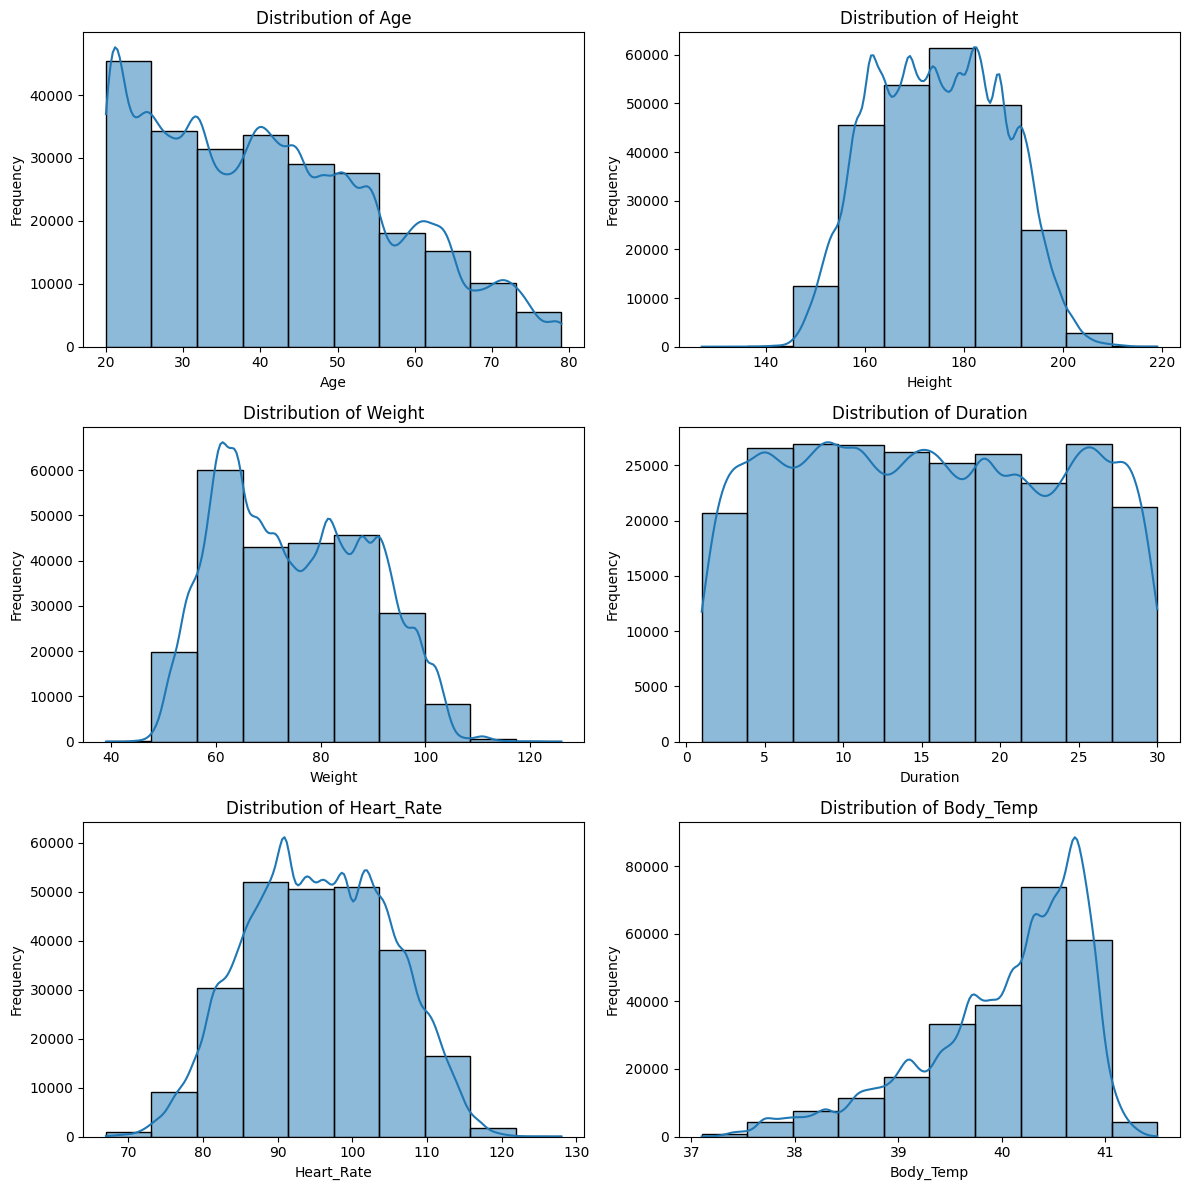

In [5]:
# Create the subplots
fig, axes = plt.subplots(num_rows, num_cols, figsize=(12, 4 * num_rows))  # Adjust figsize as needed

# Flatten the axes array to easily iterate over it
axes = axes.flatten()


# Iterate through the features and create histograms
for i, feature in enumerate(features):
    sns.histplot(data=test_df.to_pandas(), x=feature, ax=axes[i], kde=True, bins = 10)  # Added kde=True for density curve
    axes[i].set_title(f"Distribution of {feature}")
    axes[i].set_xlabel(feature)  # Ensure x-axis label is the feature name
    axes[i].set_ylabel("Frequency")

# Remove any unused subplots (if the number of features is not a multiple of num_cols)
for i in range(len(features), len(axes)):
    fig.delaxes(axes[i])

# Adjust the layout to prevent overlapping titles/labels
plt.tight_layout()

# Show the plot
plt.show()

shape: (5, 8)
┌─────┬─────┬────────┬────────┬──────────┬────────────┬───────────┬──────────┐
│ Sex ┆ Age ┆ Height ┆ Weight ┆ Duration ┆ Heart_Rate ┆ Body_Temp ┆ Calories │
│ --- ┆ --- ┆ ---    ┆ ---    ┆ ---      ┆ ---        ┆ ---       ┆ ---      │
│ i64 ┆ i64 ┆ f64    ┆ f64    ┆ f64      ┆ f64        ┆ f64       ┆ f64      │
╞═════╪═════╪════════╪════════╪══════════╪════════════╪═══════════╪══════════╡
│ 0   ┆ 36  ┆ 189.0  ┆ 82.0   ┆ 26.0     ┆ 101.0      ┆ 41.0      ┆ 150.0    │
│ 1   ┆ 64  ┆ 163.0  ┆ 60.0   ┆ 8.0      ┆ 85.0       ┆ 39.7      ┆ 34.0     │
│ 1   ┆ 51  ┆ 161.0  ┆ 64.0   ┆ 7.0      ┆ 84.0       ┆ 39.8      ┆ 29.0     │
│ 0   ┆ 20  ┆ 192.0  ┆ 90.0   ┆ 25.0     ┆ 105.0      ┆ 40.7      ┆ 140.0    │
│ 1   ┆ 38  ┆ 166.0  ┆ 61.0   ┆ 25.0     ┆ 102.0      ┆ 40.6      ┆ 146.0    │
└─────┴─────┴────────┴────────┴──────────┴────────────┴───────────┴──────────┘
Axes(0.125,0.11;0.62x0.77)


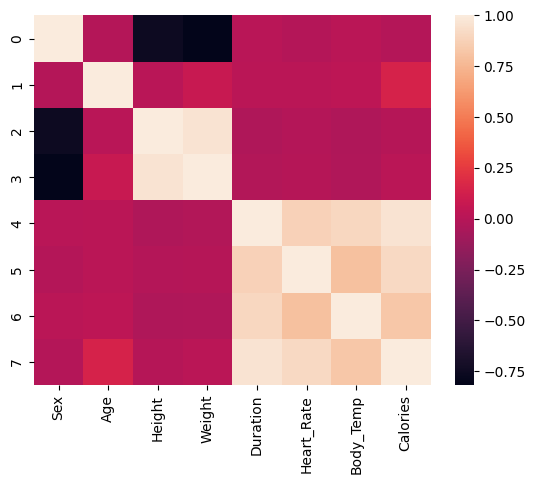

In [6]:
gender_map = {"male" : 0,
              "female" : 1}

train_df_mod = train_df.with_columns (pl.col("Sex").replace_strict (gender_map))

train_df_mod = train_df_mod.drop("id")

print (train_df_mod.head())

print (sns.heatmap(train_df_mod.corr().to_pandas()))


<Axes: xlabel='Duration', ylabel='Calories'>

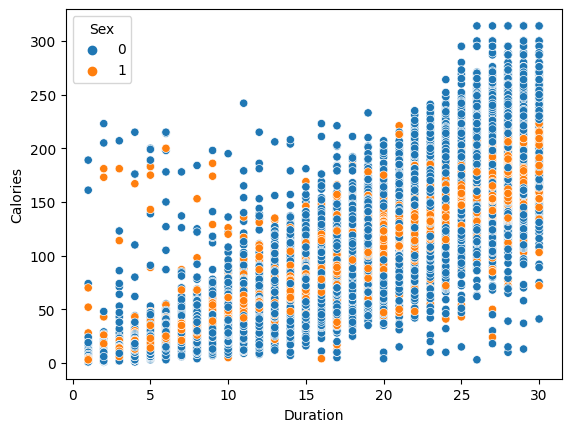

In [7]:
sns.scatterplot (data = train_df_mod.to_pandas(), x= "Duration", y = "Calories", hue = "Sex")

In [ ]:
sns.scatterplot (data = train_df_mod.to_pandas(), x= "Heart_Rate", y = "Calories", hue = "Sex")

In [ ]:
sns.scatterplot (data = train_df_mod.to_pandas(), x= "Body_Temp", y = "Calories", hue = "Sex")

These plots show a significant different distribution for male against female. We accommodate this fact by training two seperate models  

## feature engineering 

In [8]:
def remove_outliers (df : pl.DataFrame) -> pl.DataFrame :
    return  df.filter (((pl.col("Calories") / pl.col("Duration") < 11) | (pl.col("Duration") > 22)) & 
                        (pl.col("Calories") < 300))
    

AutoGluon works better with RMSE, so we convert the target to log plus_1  

In [9]:
from itertools import combinations

gender_map = {"male" : 0,
              "female" : 1}


def add_features (df : pl.DataFrame) -> pl.DataFrame :
    result = df.with_columns (pl.col("Sex").replace_strict (gender_map))
    

    feature_pairs = list(combinations(features, 2))
    for feature_pair in feature_pairs :
        a,b = feature_pair 
        result = result.with_columns ((pl.col(a) * pl.col(b)).log1p().alias (f"{a}_mult_{b}"), 
                                     (pl.col(a) / (0.001 + pl.col(b))).log1p().alias (f"{a}_div_{b}"))
    if "Calories" in df.columns :
        result = result.with_columns (pl.col("Calories").log1p().alias ("Calories_log"))
        result = result.drop ("Calories")
    return result         

train_clean = train_df.pipe (
#                remove_outliers).pipe (
                add_features )
test_clean = test_df.pipe (
    add_features)

with pl.Config (tbl_cols = 20) :
    print (train_clean.head())

print (train_clean.columns)

shape: (5, 39)
┌─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬───┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┐
│ id  ┆ Sex ┆ Age ┆ Hei ┆ Wei ┆ Dur ┆ Hea ┆ Bod ┆ Age ┆ Age ┆ … ┆ Wei ┆ Wei ┆ Wei ┆ Dur ┆ Dur ┆ Dur ┆ Dur ┆ Hea ┆ Hea ┆ Cal │
│ --- ┆ --- ┆ --- ┆ ght ┆ ght ┆ ati ┆ rt_ ┆ y_T ┆ _mu ┆ _di ┆   ┆ ght ┆ ght ┆ ght ┆ ati ┆ ati ┆ ati ┆ ati ┆ rt_ ┆ rt_ ┆ ori │
│ i64 ┆ i64 ┆ i64 ┆ --- ┆ --- ┆ on  ┆ Rat ┆ emp ┆ lt_ ┆ v_H ┆   ┆ _di ┆ _mu ┆ _di ┆ on_ ┆ on_ ┆ on_ ┆ on_ ┆ Rat ┆ Rat ┆ es_ │
│     ┆     ┆     ┆ f64 ┆ f64 ┆ --- ┆ e   ┆ --- ┆ Hei ┆ eig ┆   ┆ v_H ┆ lt_ ┆ v_B ┆ mul ┆ div ┆ mul ┆ div ┆ e_m ┆ e_d ┆ log │
│     ┆     ┆     ┆     ┆     ┆ f64 ┆ --- ┆ f64 ┆ ght ┆ ht  ┆   ┆ ear ┆ Bod ┆ ody ┆ t_H ┆ _He ┆ t_B ┆ _Bo ┆ ult ┆ iv_ ┆ --- │
│     ┆     ┆     ┆     ┆     ┆     ┆ f64 ┆     ┆ --- ┆ --- ┆   ┆ t_R ┆ y_T ┆ _Te ┆ ear ┆ art ┆ ody ┆ dy_ ┆ _Bo ┆ Bod ┆ f64 │
│     ┆     ┆     ┆     ┆     ┆     ┆     ┆     ┆ f64 ┆ f64 ┆   ┆ ate ┆ emp ┆ mp  ┆ t_R ┆ _Ra ┆ _Te ┆ T

In [10]:
train_clean_male = train_clean.filter(pl.col("Sex") ==  0) 
train_clean_female = train_clean.filter(pl.col("Sex") ==  1)
test_clean_male = test_clean.filter(pl.col("Sex") ==  0)
test_clean_female = test_clean.filter(pl.col("Sex") ==  1)

In [11]:
!pip install ray==2.10.0
!pip install scikit-learn==1.5.2
!pip install autogluon.tabular --no-cache-dir -q
!pip install -U ipywidgets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.6/65.6 MB 23.4 MB/s eta 0:00:00:00:0100:01
  Attempting uninstall: ray
    Found existing installation: ray 2.44.1
    Uninstalling ray-2.44.1:
      Successfully uninstalled ray-2.44.1
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.3/13.3 MB 87.9 MB/s eta 0:00:00:00:010:01
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.2.2
    Uninstalling scikit-learn-1.2.2:
      Successfully uninstalled scikit-learn-1.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 1.36.0 requires rich<14,>=12.4.4, but you have rich 14.0.0 which is incompatible.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 382.4/382.4 kB 45.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 222.7/222.7 kB 292.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.2/64.2 kB 237.8 MB/s eta 

## Training with AutoGluon

In [21]:

from autogluon.tabular import TabularPredictor

predictor_male= TabularPredictor(path = '/kaggle/working/Autogluon/male',
                                       label='Calories_log', 
                               problem_type = 'regression', 
                               eval_metric =  'root_mean_squared_error',  
                               # sample_weight = 'my_weight',
                               verbosity  = 1,
                               learner_kwargs = {'ignored_columns' : [
                                   'id',
                                   'Sex', 
                                   'Age_div_Weight',
                                   'Age_div_Height',
                                   'Height_mult_Weight',
                                   'Weight_div_Body_Temp',
                                   'Height_div_Body_Temp'
                               #   'my_weight'
                                    ]})



In [19]:
train_clean_male1 = train_clean_male.sample (fraction = 0.75, shuffle = True) 
train_clean_male2 = train_clean_male.join (train_clean_male1, on = "id", how = "anti")

print (f"{train_clean_male1.shape = },  {train_clean_male2.shape = }")

train_clean_male1.shape = (280709, 39),  train_clean_male2.shape = (93570, 39)


In [22]:
predictor_male.fit(train_data= train_clean_male.to_pandas(), 
                        presets= 'best_quality',
    # best_quality, high_quality, medium_quality, 'experimental_quality',                         
                        time_limit = 19000,
                        # num_gpus=1,
#                        raise_on_no_models_fitted = True,
#                        dynamic_stacking=False, 
#                        num_stack_levels=1,
                        #hyperparameters=custom_hyperparameters,
#                         hyperparameters = my_search_hyperparameters  ,
#                         hyperparameter_tune_kwargs=hyperparameter_tune_kwargs,
                        )

In [24]:
display (predictor_male.leaderboard())

# display (predictor_male.feature_importance (train_clean_male2.to_pandas()))



print  (f"{ predictor_male.predict_oof() = }")

,model,score_val,eval_metric,pred_time_val,fit_time,pred_time_val_marginal,fit_time_marginal,stack_level,can_infer,fit_order
0,WeightedEnsemble_L2,-0.068324,root_mean_squared_error,1.072489,831.862960,0.000531,0.010649,2,True,6
1,RandomForestMSE,-0.069350,root_mean_squared_error,0.166351,798.150753,0.166351,798.150753,1,True,5
2,LightGBM,-0.070437,root_mean_squared_error,0.052262,14.982725,0.052262,14.982725,1,True,4
3,LightGBMXT,-0.071493,root_mean_squared_error,0.092774,18.083657,0.092774,18.083657,1,True,3
4,KNeighborsDist,-0.091093,root_mean_squared_error,0.760571,0.635177,0.760571,0.635177,1,True,2
5,KNeighborsUnif,-0.092891,root_mean_squared_error,0.764612,0.668425,0.764612,0.668425,1,True,1


These features in provided data are not utilized by the predictor and will be ignored: ['Sex']


,importance,stddev,p_value,n,p99_high,p99_low
Duration_mult_Heart_Rate,0.797113,0.019577,4.362331e-08,5,0.837422,0.756805
Heart_Rate_mult_Body_Temp,0.125620,0.003132,4.634191e-08,5,0.132069,0.119171
Age_mult_Duration,0.100722,0.003240,1.282808e-07,5,0.107393,0.094051
Age_mult_Heart_Rate,0.035370,0.001516,4.038898e-07,5,0.038491,0.032249
Duration,0.029003,0.001163,3.100719e-07,5,0.031398,0.026607
Heart_Rate,0.021804,0.001708,4.479099e-06,5,0.025320,0.018287
Heart_Rate_div_Body_Temp,0.011832,0.001146,1.044687e-05,5,0.014193,0.009471
Body_Temp,0.006865,0.000588,6.405288e-06,5,0.008076,0.005654
Age_mult_Weight,0.006538,0.000475,3.320879e-06,5,0.007516,0.005560
Weight_mult_Duration,0.006440,0.000281,4.362812e-07,5,0.007020,0.005861


AssertionError: Predictor must be in bagged mode to get out-of-fold predictions.

Female distribution looks more linear, so the CV value is expected to be higher 

In [15]:
predictor_female= TabularPredictor(path = '/kaggle/working/Autogluon/female',
                                       label='Calories_log', 
                                problem_type = 'regression', 
                               eval_metric =  'root_mean_squared_error',  
                               # sample_weight = 'my_weight',
                               verbosity  = 1,
                               learner_kwargs = {'ignored_columns' : [
                                    'id',
                                   'Sex', 
                                   'Age_div_Weight',
                                   'Age_div_Height',
                                   'Height_mult_Weight',
                                   'Weight_div_Body_Temp',
                                   'Height_div_Body_Temp'
                               #   'my_weight'
                                    ]})

In [16]:
predictor_female.fit(train_data= train_clean_female.to_pandas(), 
                        presets= 'best_quality',
    # best_quality, high_quality, medium_quality, 'experimental_quality',                         
                        time_limit = 16000,
                        # num_gpus=1,
#                        raise_on_no_models_fitted = True,
#                        dynamic_stacking=False, 
#                        num_stack_levels=1,
                        #hyperparameters=custom_hyperparameters,
#                         hyperparameters = my_search_hyperparameters  ,
#                         hyperparameter_tune_kwargs=hyperparameter_tune_kwargs,
                        )




In [17]:
display (predictor_female.leaderboard())

print  (f"{ predictor_female.predict_oof() = }")

,model,score_val,eval_metric,pred_time_val,fit_time,pred_time_val_marginal,fit_time_marginal,stack_level,can_infer,fit_order
0,WeightedEnsemble_L2,-0.053885,root_mean_squared_error,2.609424,155.156098,0.000515,0.008508,2,True,4
1,LightGBMXT,-0.054016,root_mean_squared_error,1.276397,154.444724,1.276397,154.444724,1,True,3
2,KNeighborsDist,-0.072975,root_mean_squared_error,1.354935,0.727954,1.354935,0.727954,1,True,2
3,KNeighborsUnif,-0.073966,root_mean_squared_error,1.332512,0.702865,1.332512,0.702865,1,True,1


AssertionError: Predictor must be in bagged mode to get out-of-fold predictions.

## Forecasting on Test Dataset

In [ ]:
predictions_male = predictor_male.predict (test_clean_male.to_pandas()) 
print (predictions_male)

In [ ]:
predictions_female = predictor_female.predict (test_clean_female.to_pandas()) 
print (predictions_female)

## Submission

assuming that the target remains within the bounds of the training data, we clip to the min and max values. rounding down should give a slight advantage   

In [ ]:
def convert (pred, test) -> pl.DataFrame :
    converted = pl.Series ("Calories", np.exp(pred) -1) 
    result = test.select ("id")
    result = result.with_columns (converted.alias ("Calories"))
    result = result.with_columns (pl.col("Calories").clip (lower_bound = 1.0, upper_bound = 314.0).floor())
    return result

submission_male = convert (predictions_male, test_clean_male)
submission_female = convert (predictions_female, test_clean_female)

submission = pl.concat ([submission_male, submission_female])

In [ ]:
submission.describe()

In [ ]:
submission.write_csv("submission.csv")
print ("submission complete")

In [ ]:

import zipfile

def move_2_zip (directory_path, archive_name):

    """
    Generated bi Gen AI (Gemini 2.0 flash)
  Zips a directory and all its subdirectories and files into a zip archive.

  Args:
    directory_path: The path to the directory to zip.
    archive_name: The name (including the .zip extension) of the zip archive to create.

  Returns:
    True if the zipping was successful, False otherwise.
    Prints error messages to the console if any issues occur.
  """
    try:
        with zipfile.ZipFile(archive_name, 'w', zipfile.ZIP_DEFLATED) as zipf:
          for root, _, files in os.walk(directory_path):
            for filename in files:
                file_path = os.path.join(root, filename)
                relative_path = os.path.relpath(file_path, directory_path)  # Path relative to the root directory
                try:
                    zipf.write(file_path, relative_path)
                    os.remove(file_path) #Remove file after successful zip
                except Exception as e:
                    print(f"Error zipping/deleting file {filename}: {e}")
                    return False

        print(f"Successfully zipped '{directory_path}' to '{archive_name}' and deleted original files.")
        return True

    except Exception as e:
        print(f"An error occurred: {e}")
        return False


move_2_zip ("/kaggle/working/Autogluon", "/kaggle/working/artifacts")